In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pickle
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv('../.env')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Setup complete")

Setup complete


In [3]:
from src.ml.feature_engineering import build_feature_matrix, get_X_y
from src.utils.constants import FEATURE_COLS, TARGET_COL

# Load data
price_df = pd.read_csv('../data/raw/AAPL/price_data.csv')
news_df  = pd.read_csv('../data/processed/AAPL/news_enriched.csv')

price_df['date']        = pd.to_datetime(price_df['date'],        utc=True)
news_df['published_at'] = pd.to_datetime(news_df['published_at'], utc=True, errors='coerce')

# Build feature matrix
feature_df = build_feature_matrix(price_df, news_df)
X, y       = get_X_y(feature_df)

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target distribution:\n{y.value_counts().to_frame('count').assign(pct=lambda d: d['count']/len(y))}")

# Load trained model
with open('../models/AAPL_xgb_model.pkl', 'rb') as f:
    model_dict = pickle.load(f)

model        = model_dict['model']
feature_cols = model_dict['feature_cols']
test_metrics = model_dict['test_metrics']

print(f"\nModel loaded | CV F1: {model_dict['cv_mean_f1']:.3f}")
print(f"Test metrics: {test_metrics}")

2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Building feature matrix...
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Daily sentiment: 3 rows
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Price date range: 2025-05-09 to 2026-05-07
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Sentiment date range: 2026-05-08 to 2026-05-10
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Rows after merge: 250
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Merge complete | price rows: 250 | sentiment rows: 3 | merged rows: 250
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Target distribution: {1: 0.528, 0: 0.472}
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | Feature matrix ready | rows=250 | features=11 | target_col=price_direction
2026-05-13 12:41:30 | INFO     | src.ml.feature_engineering | X shape: (250, 11) | y distribution: {1: 132, 0: 118}


Feature matrix: 250 rows × 11 features
Target distribution:
                 count    pct
price_direction              
1                  132  0.528
0                  118  0.472

Model loaded | CV F1: 0.553
Test metrics: {'accuracy': 0.54, 'f1': 0.5818, 'precision': 0.5517, 'recall': 0.6154, 'roc_auc': 0.5881, 'log_loss': 0.821, 'confusion_matrix': [[11, 13], [10, 16]], 'n_test_samples': 50, 'positive_rate': 0.52}


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y,
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Test class balance: {y_test.mean():.1%} up days")

Train: 200 | Test: 50
Test class balance: 52.0% up days


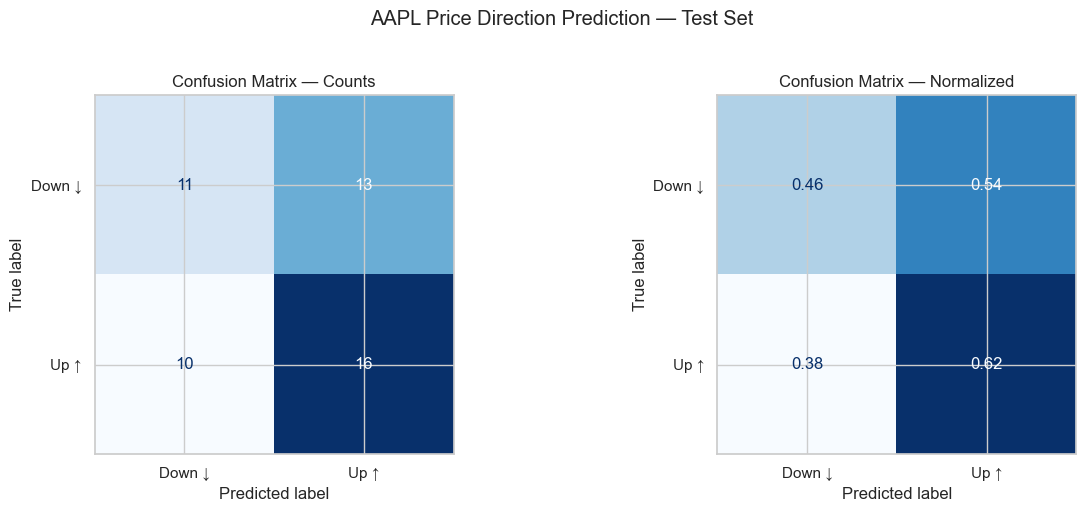


True Negatives  (correctly predicted Down): 11
True Positives  (correctly predicted Up):   16
False Positives (predicted Up, was Down):   13
False Negatives (predicted Down, was Up):   10

False Alarm Rate: 54.2%
Miss Rate:        38.5%


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute counts
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Down ↓', 'Up ↑'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2   = ConfusionMatrixDisplay(cm_norm, display_labels=['Down ↓', 'Up ↑'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Normalized')

plt.suptitle('AAPL Price Direction Prediction — Test Set', y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted Down): {tn}")
print(f"True Positives  (correctly predicted Up):   {tp}")
print(f"False Positives (predicted Up, was Down):   {fp}")
print(f"False Negatives (predicted Down, was Up):   {fn}")
print(f"\nFalse Alarm Rate: {fp/(fp+tn):.1%}")
print(f"Miss Rate:        {fn/(fn+tp):.1%}")

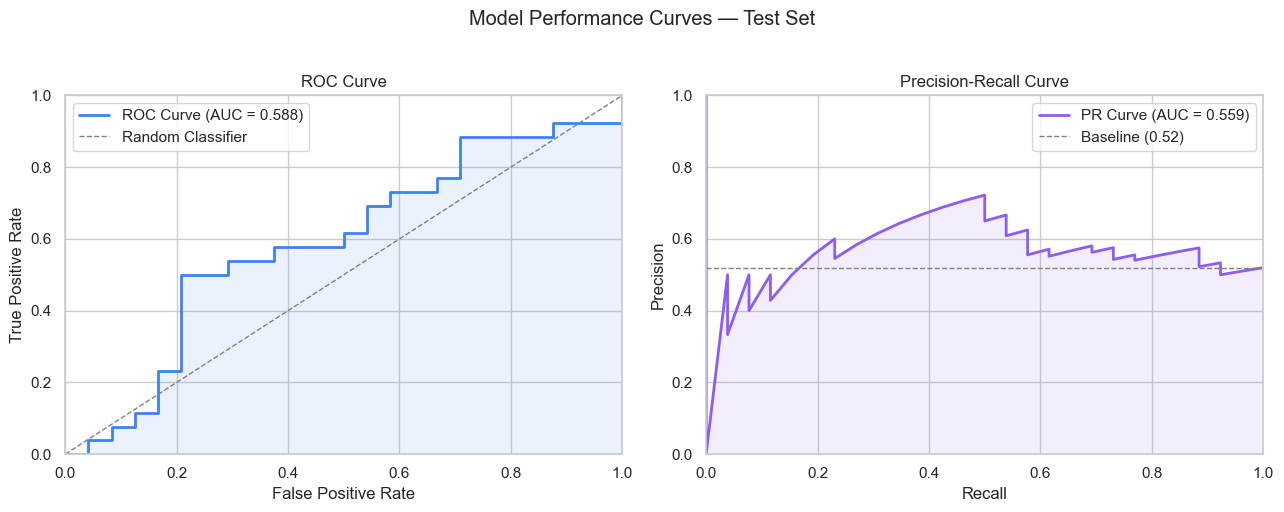

ROC-AUC:  0.5881  (0.5 = random, 1.0 = perfect)
PR-AUC:   0.5590  (baseline = 0.5200)


In [6]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#3b82f6', linewidth=2,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--',
             linewidth=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3b82f6')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
baseline = y_test.mean()

axes[1].plot(recall, precision, color='#8b5cf6', linewidth=2,
             label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].axhline(baseline, color='gray', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline:.2f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#8b5cf6')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Model Performance Curves — Test Set', y=1.02)
plt.tight_layout()
plt.show()

print(f"ROC-AUC:  {roc_auc:.4f}  (0.5 = random, 1.0 = perfect)")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline = {baseline:.4f})")

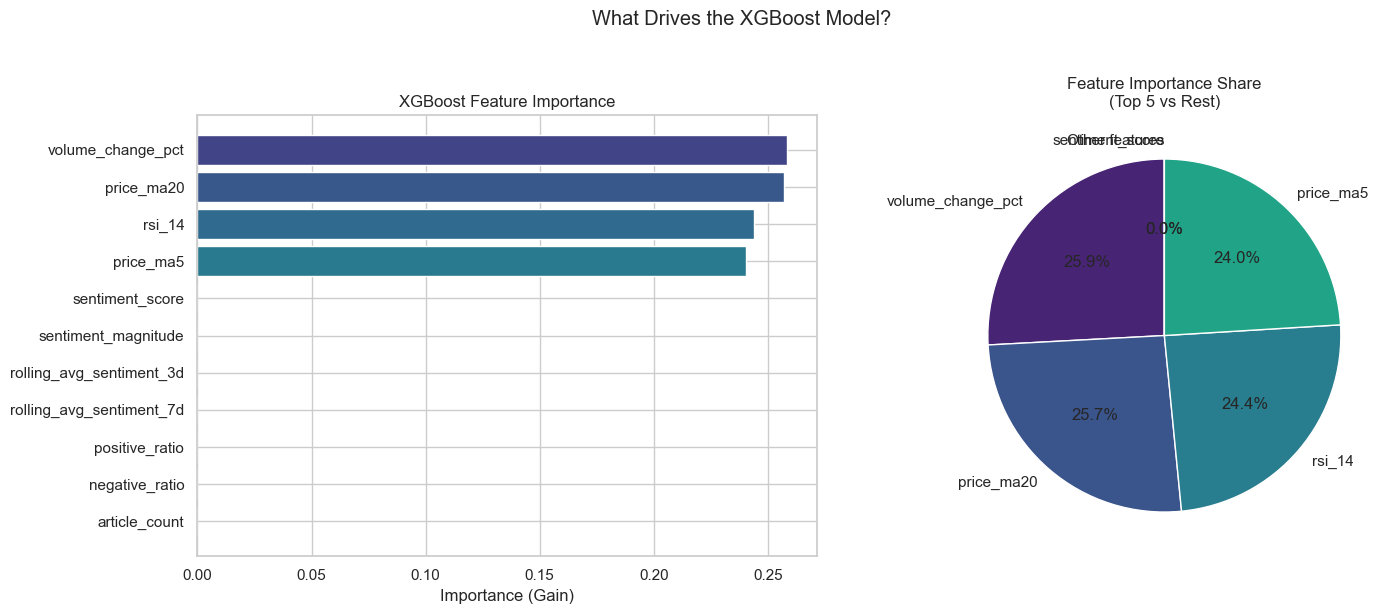


Top 5 features:
  volume_change_pct                   0.2585
  price_ma20                          0.2570
  rsi_14                              0.2441
  price_ma5                           0.2403
  sentiment_score                     0.0000


In [7]:
clf          = model.named_steps['clf']
importances  = clf.feature_importances_
available    = [c for c in feature_cols if c in X.columns]

fi_df = pd.DataFrame({
    'Feature':    available[:len(importances)],
    'Importance': importances,
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_df)))
axes[0].barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
             color=colors[::-1])
axes[0].set_xlabel('Importance (Gain)')
axes[0].set_title('XGBoost Feature Importance')

# Pie chart — top 5 vs rest
top5    = fi_df.head(5)
rest    = pd.DataFrame([{
    'Feature':    'Other features',
    'Importance': fi_df.tail(len(fi_df)-5)['Importance'].sum()
}])
pie_df  = pd.concat([top5, rest])

axes[1].pie(
    pie_df['Importance'],
    labels   = pie_df['Feature'],
    autopct  = '%1.1f%%',
    startangle = 90,
    colors   = plt.cm.viridis(np.linspace(0.1, 0.9, len(pie_df))),
)
axes[1].set_title('Feature Importance Share\n(Top 5 vs Rest)')

plt.suptitle('What Drives the XGBoost Model?', y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for _, row in fi_df.head(5).iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}")

Running 5-fold cross-validation...


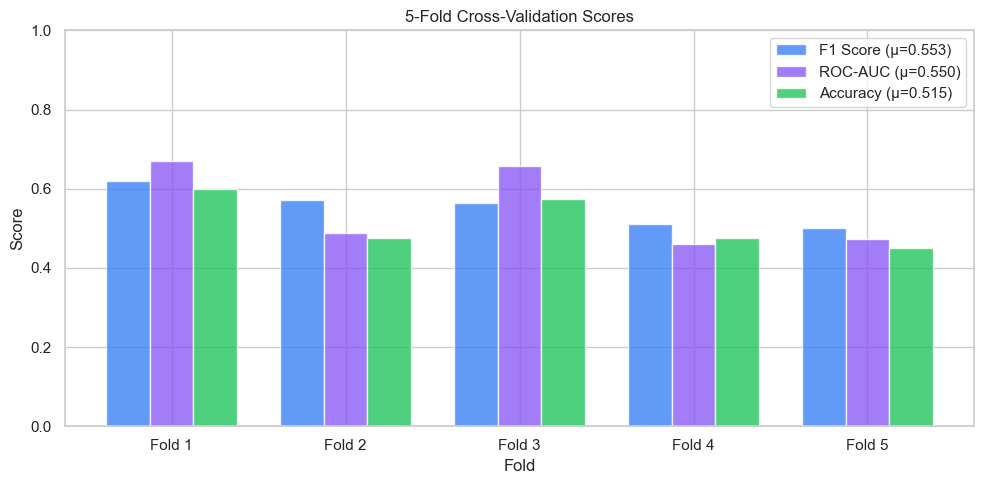


CV Results:
  F1:       0.553 ± 0.043
  ROC-AUC:  0.550 ± 0.093
  Accuracy: 0.515 ± 0.060


In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from src.ml.train import build_model_pipeline

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fresh  = build_model_pipeline()

print("Running 5-fold cross-validation...")
cv_f1  = cross_val_score(fresh, X_train, y_train, cv=cv, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(fresh, X_train, y_train, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(fresh, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 5))

metrics_cv = {
    'F1 Score':  cv_f1,
    'ROC-AUC':   cv_auc,
    'Accuracy':  cv_acc,
}

x      = np.arange(5)
width  = 0.25
colors = ['#3b82f6', '#8b5cf6', '#22c55e']

for i, (name, scores) in enumerate(metrics_cv.items()):
    bars = ax.bar(x + i*width, scores, width,
                  label=f'{name} (μ={scores.mean():.3f})',
                  color=colors[i], alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation Scores')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nCV Results:")
print(f"  F1:       {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
print(f"  ROC-AUC:  {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"  Accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

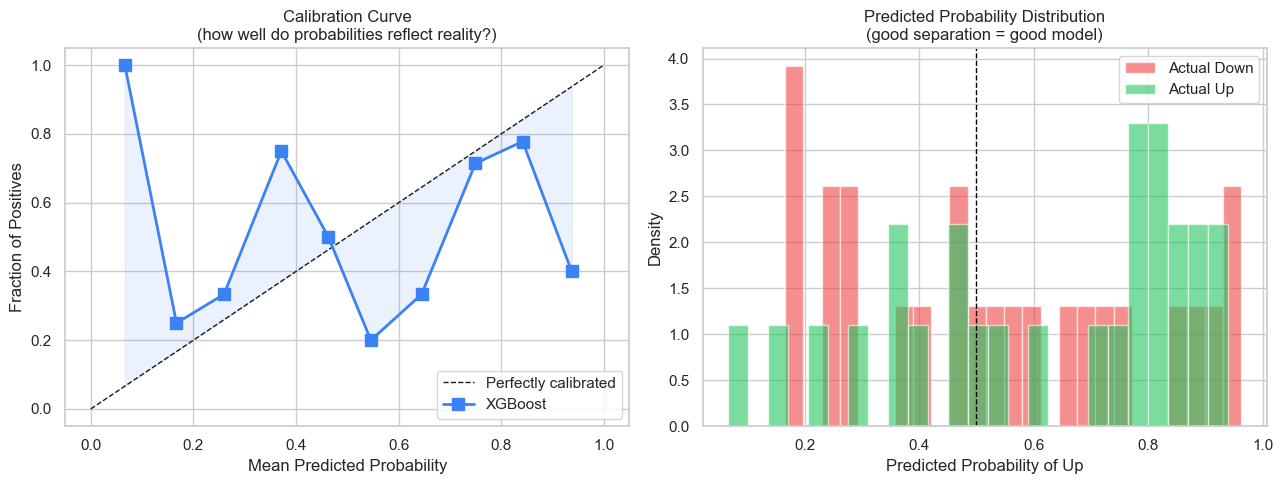

Calibration insight:
A well-calibrated model that predicts 70% confidence
should be correct ~70% of the time.


In [9]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curve
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Perfectly calibrated')
axes[0].plot(mean_pred, fraction_pos, 's-', color='#3b82f6',
             linewidth=2, markersize=8, label='XGBoost')
axes[0].fill_between(mean_pred, fraction_pos, mean_pred,
                     alpha=0.1, color='#3b82f6')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve\n(how well do probabilities reflect reality?)')
axes[0].legend()

# Probability distribution
axes[1].hist(y_prob[y_test==0], bins=25, alpha=0.6,
             color='#ef4444', label='Actual Down', density=True)
axes[1].hist(y_prob[y_test==1], bins=25, alpha=0.6,
             color='#22c55e', label='Actual Up',   density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Probability of Up')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution\n(good separation = good model)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Calibration insight:")
print("A well-calibrated model that predicts 70% confidence")
print("should be correct ~70% of the time.")

In [10]:
from src.ml.evaluate import compute_sharpe_ratio

# Reconstruct test period predictions with dates
test_df = feature_df.iloc[int(len(feature_df)*0.8):].copy()
test_df = test_df.reset_index(drop=True)

available_features = [c for c in feature_cols if c in test_df.columns]
X_test_full        = test_df[available_features].fillna(0)

test_df['up_probability']      = model.predict_proba(X_test_full)[:, 1]
test_df['predicted_direction'] = model.predict(X_test_full)

# Daily returns
test_df['daily_return_decimal'] = test_df.get(
    'daily_return', pd.Series(0, index=test_df.index)
) / 100

# Strategy: go long only when model predicts up
test_df['strategy_return']  = np.where(
    test_df['predicted_direction'] == 1,
    test_df['daily_return_decimal'], 0
)
test_df['buyhold_return']   = test_df['daily_return_decimal']

# Cumulative returns
test_df['strategy_cumret']  = (1 + test_df['strategy_return']).cumprod() - 1
test_df['buyhold_cumret']   = (1 + test_df['buyhold_return']).cumprod() - 1

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x    = test_df['date'] if 'date' in test_df.columns else test_df.index,
    y    = test_df['strategy_cumret'] * 100,
    name = 'Model Strategy',
    mode = 'lines',
    line = dict(color='#3b82f6', width=2),
))
fig.add_trace(go.Scatter(
    x    = test_df['date'] if 'date' in test_df.columns else test_df.index,
    y    = test_df['buyhold_cumret'] * 100,
    name = 'Buy & Hold',
    mode = 'lines',
    line = dict(color='#94a3b8', width=2, dash='dash'),
))
fig.add_hline(y=0, line_dash='dot', line_color='black', line_width=1)

fig.update_layout(
    title     = 'Strategy Backtest — Model vs Buy & Hold',
    xaxis_title = 'Date',
    yaxis_title = 'Cumulative Return (%)',
    height    = 420,
    hovermode = 'x unified',
)
fig.show()

strat_sharpe = compute_sharpe_ratio(test_df['strategy_return'].values)
bh_sharpe    = compute_sharpe_ratio(test_df['buyhold_return'].values)
strat_ret    = test_df['strategy_cumret'].iloc[-1]
bh_ret       = test_df['buyhold_cumret'].iloc[-1]

print(f"\nBacktest Results:")
print(f"  Strategy return:      {strat_ret:.1%}")
print(f"  Buy & Hold return:    {bh_ret:.1%}")
print(f"  Strategy Sharpe:      {strat_sharpe:.3f}")
print(f"  Buy & Hold Sharpe:    {bh_sharpe:.3f}")
print(f"  Days traded:          {test_df['predicted_direction'].sum()} / {len(test_df)}")


Backtest Results:
  Strategy return:      0.3%
  Buy & Hold return:    4.8%
  Strategy Sharpe:      -0.093
  Buy & Hold Sharpe:    0.922
  Days traded:          34 / 50


In [11]:
from sklearn.metrics import classification_report

print("=" * 55)
print("ML MODEL SUMMARY — AAPL XGBoost")
print("=" * 55)

print(f"\n📊 CROSS-VALIDATION (5-fold, training set)")
print(f"   F1 Score:   {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
print(f"   ROC-AUC:    {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"   Accuracy:   {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

print(f"\n🎯 TEST SET (held-out 20%)")
print(f"   Accuracy:   {test_metrics.get('accuracy', 0):.3f}")
print(f"   F1 Score:   {test_metrics.get('f1', 0):.3f}")
print(f"   ROC-AUC:    {test_metrics.get('roc_auc', 0):.3f}")
print(f"   Precision:  {test_metrics.get('precision', 0):.3f}")
print(f"   Recall:     {test_metrics.get('recall', 0):.3f}")

print(f"\n💰 BACKTEST")
print(f"   Strategy return:   {strat_ret:.1%}")
print(f"   Buy & Hold return: {bh_ret:.1%}")
print(f"   Strategy Sharpe:   {strat_sharpe:.3f}")
print(f"   B&H Sharpe:        {bh_sharpe:.3f}")

print(f"\n🔑 TOP FEATURE: {fi_df.iloc[0]['Feature']}")
print(f"   Importance: {fi_df.iloc[0]['Importance']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
print("=" * 55)

ML MODEL SUMMARY — AAPL XGBoost

📊 CROSS-VALIDATION (5-fold, training set)
   F1 Score:   0.553 ± 0.043
   ROC-AUC:    0.550 ± 0.093
   Accuracy:   0.515 ± 0.060

🎯 TEST SET (held-out 20%)
   Accuracy:   0.540
   F1 Score:   0.582
   ROC-AUC:    0.588
   Precision:  0.552
   Recall:     0.615

💰 BACKTEST
   Strategy return:   0.3%
   Buy & Hold return: 4.8%
   Strategy Sharpe:   -0.093
   B&H Sharpe:        0.922

🔑 TOP FEATURE: volume_change_pct
   Importance: 0.2585

Classification Report:
              precision    recall  f1-score   support

        Down       0.52      0.46      0.49        24
          Up       0.55      0.62      0.58        26

    accuracy                           0.54        50
   macro avg       0.54      0.54      0.54        50
weighted avg       0.54      0.54      0.54        50

